# 🏠 Home Loan Approval — Complete EDA & ML Pipeline
### Dataset: home_loan_dataset.csv
**Workflow:**
1. Data Loading & Exploration
2. Missing Value Handling
3. Outlier Treatment
4. Feature Engineering
5. EDA Visualizations
6. Part 1: Classification (Random Forest + Logistic Regression)
7. Part 2: Regression (Linear + Random Forest)
8. Part 3: Clustering (KMeans)


## 📦 Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, r2_score

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 📂 Step 2: Load Dataset

In [ ]:
df = pd.read_csv('Data/home_loan_dataset.csv')
print("Shape:", df.shape)
df.head()

Shape: (315, 21)


,name,age,city_tier,employment_type,monthly_income,co_applicant_income,existing_emi,dti,cibil_score,property_value,...,loan_amount_requested,ltv,property_age,builder_grade,legal_issue_flag,tenure_years,job_tenure_months,loan_status,approved_amount,interest_rate
0,Meera Yadav,34.0,Metro,Salaried,69934.0,17565.0,5611.0,0.080,818.0,7213630.0,...,4789338.0,0.664,35.0,A,0.0,NaN,22.0,0.0,0.0,NaN
1,Vivek Kapoor,25.0,Rural,Salaried,57235.0,21597.0,14468.0,0.253,690.0,13684274.0,...,11021012.0,0.805,36.0,B,0.0,NaN,12.0,0.0,0.0,NaN
2,Rahul Gupta,NaN,Metro,NaN,72954.0,41209.0,18385.0,0.252,789.0,16349073.0,...,11339056.0,0.694,21.0,B,0.0,20.0,NaN,1.0,9118200.0,12.04
3,Yash Reddy,35.0,Metro,Self-Employed,90461.0,39156.0,20300.0,0.224,729.0,15483418.0,...,11902399.0,0.769,11.0,B,1.0,20.0,NaN,0.0,0.0,NaN
4,Kunal Reddy,35.0,Urban,Salaried,55317.0,29686.0,13436.0,0.243,738.0,16158459.0,...,13308088.0,0.824,NaN,B,0.0,30.0,47.0,0.0,0.0,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 315 entries, 0 to 314
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   276 non-null    object 
 1   age                    290 non-null    float64
 2   city_tier              289 non-null    object 
 3   employment_type        291 non-null    object 
 4   monthly_income         290 non-null    float64
 5   co_applicant_income    290 non-null    float64
 6   existing_emi           290 non-null    float64
 7   dti                    290 non-null    float64
 8   cibil_score            290 non-null    float64
 9   property_value         290 non-null    float64
 10  down_payment           289 non-null    float64
 11  loan_amount_requested  287 non-null    float64
 12  ltv                    290 non-null    float64
 13  property_age           289 non-null    float64
 14  builder_grade          290 non-null    object 
 15  legal_

In [4]:
df.describe()

,age,monthly_income,co_applicant_income,existing_emi,dti,cibil_score,property_value,down_payment,loan_amount_requested,ltv,property_age,legal_issue_flag,tenure_years,job_tenure_months,loan_status,approved_amount,interest_rate
count,290.000000,2.900000e+02,290.000000,290.000000,290.000000,290.000000,2.900000e+02,2.890000e+02,2.870000e+02,290.000000,289.000000,290.000000,289.000000,290.000000,306.000000,2.900000e+02,169.000000
mean,36.375862,1.004878e+05,29628.289655,10319.382759,0.169131,748.537931,1.302583e+07,2.573555e+06,9.630922e+06,0.748034,20.155709,0.037931,20.536332,49.755172,0.584967,3.490173e+06,12.526805
std,6.694012,2.284843e+05,14273.956036,7366.862884,0.102990,48.174498,1.640738e+07,1.639100e+06,1.171874e+07,0.085210,11.301732,0.191360,6.035735,45.426987,0.493535,3.854121e+06,0.503116
min,21.000000,1.000000e+04,0.000000,74.000000,0.002000,595.000000,1.109415e+06,1.431020e+05,6.972440e+05,0.600000,0.000000,0.000000,10.000000,1.000000,0.000000,0.000000e+00,11.310000
25%,32.000000,4.653750e+04,18684.500000,4550.000000,0.080250,716.000000,5.593662e+06,1.349030e+06,4.048542e+06,0.676000,11.000000,0.000000,15.000000,16.000000,0.000000,0.000000e+00,12.160000
50%,36.000000,6.136100e+04,29700.500000,9315.000000,0.167500,750.000000,1.035758e+07,2.407706e+06,7.973750e+06,0.738500,20.000000,0.000000,20.000000,35.500000,1.000000,2.131572e+06,12.510000
75%,41.000000,7.350475e+04,39198.750000,14669.750000,0.253750,777.750000,1.542591e+07,3.454312e+06,1.136568e+07,0.821750,30.000000,0.000000,25.000000,70.750000,1.000000,6.856805e+06,12.870000
max,58.000000,1.370550e+06,76183.000000,34126.000000,0.349000,863.000000,9.968620e+07,7.388728e+06,7.036800e+07,0.899000,39.000000,1.000000,30.000000,240.000000,1.000000,1.331505e+07,13.990000


## 🔍 Step 3: Basic EDA Checks

### 3.1 — Missing Values

In [5]:
missing = (df.isnull().sum() / len(df)) * 100
missing = missing[missing > 0].sort_values(ascending=False)
print("Missing Values (%):")
print(missing)

Missing Values (%):
interest_rate            46.349206
name                     12.380952
loan_amount_requested     8.888889
property_age              8.253968
tenure_years              8.253968
city_tier                 8.253968
down_payment              8.253968
existing_emi              7.936508
dti                       7.936508
cibil_score               7.936508
property_value            7.936508
age                       7.936508
ltv                       7.936508
co_applicant_income       7.936508
builder_grade             7.936508
legal_issue_flag          7.936508
monthly_income            7.936508
job_tenure_months         7.936508
approved_amount           7.936508
employment_type           7.619048
loan_status               2.857143
dtype: float64


### 3.2 — Duplicates

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 14


### 3.3 — Target Distribution

In [7]:
print("Loan Status Distribution:")
print(df['loan_status'].value_counts())
print()
print("Percentage:")
print(df['loan_status'].value_counts(normalize=True) * 100)

Loan Status Distribution:
loan_status
1.0    179
0.0    127
Name: count, dtype: int64

Percentage:
loan_status
1.0    58.496732
0.0    41.503268
Name: proportion, dtype: float64


## 📊 Step 4: Visualizations

### 4.1 — Numeric Columns Histograms

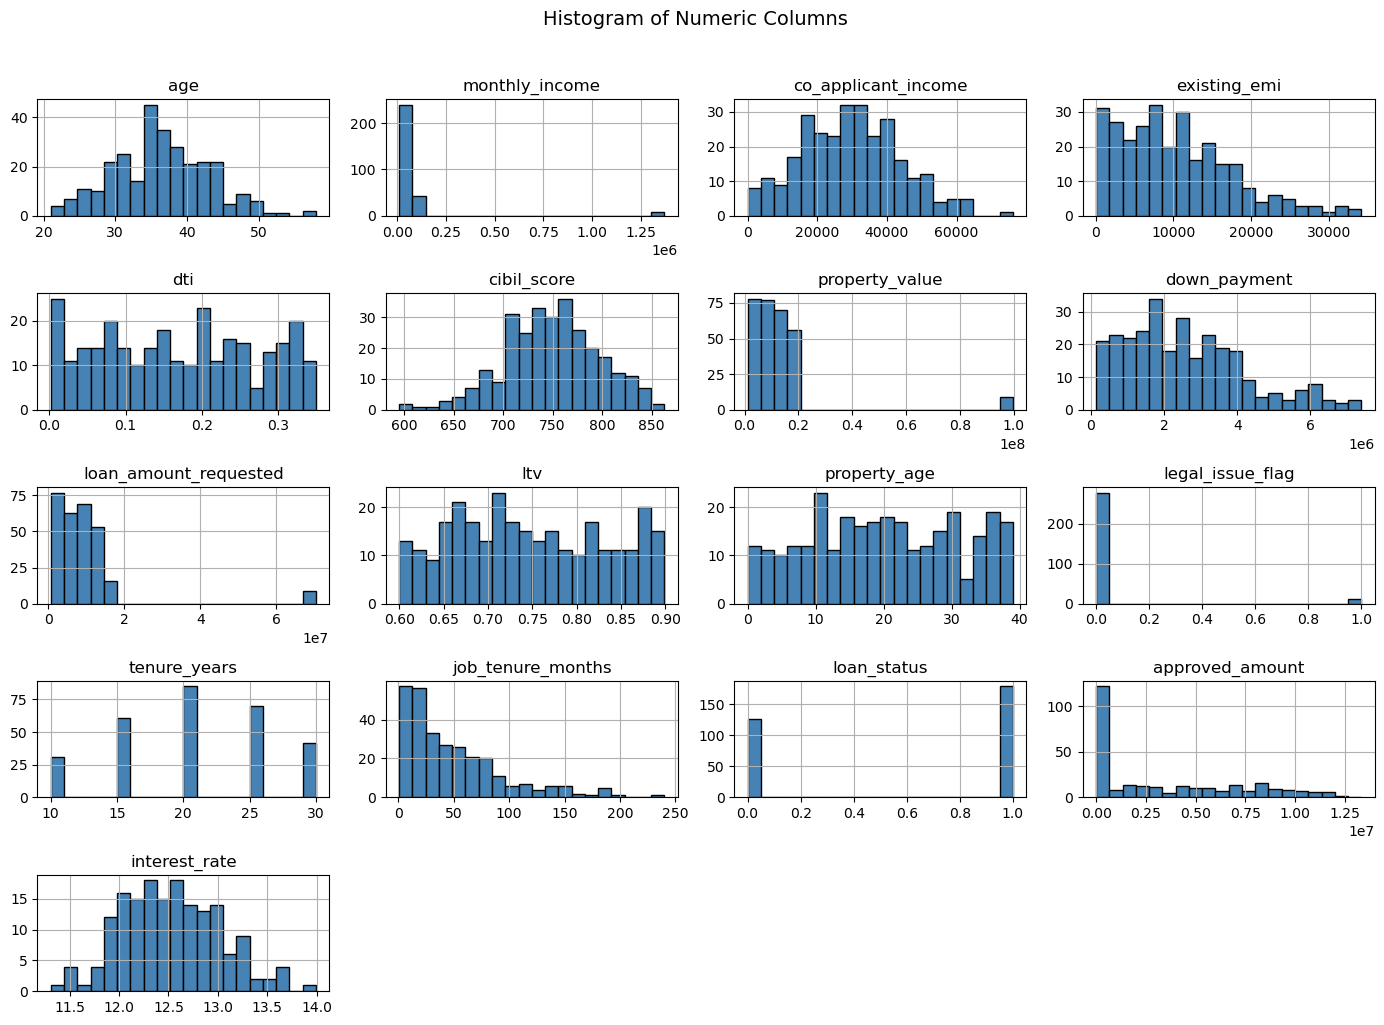

In [8]:
num_cols = df.select_dtypes(include='number').columns.tolist()
df[num_cols].hist(figsize=(14, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Histogram of Numeric Columns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4.2 — Boxplots (Outlier Detection)

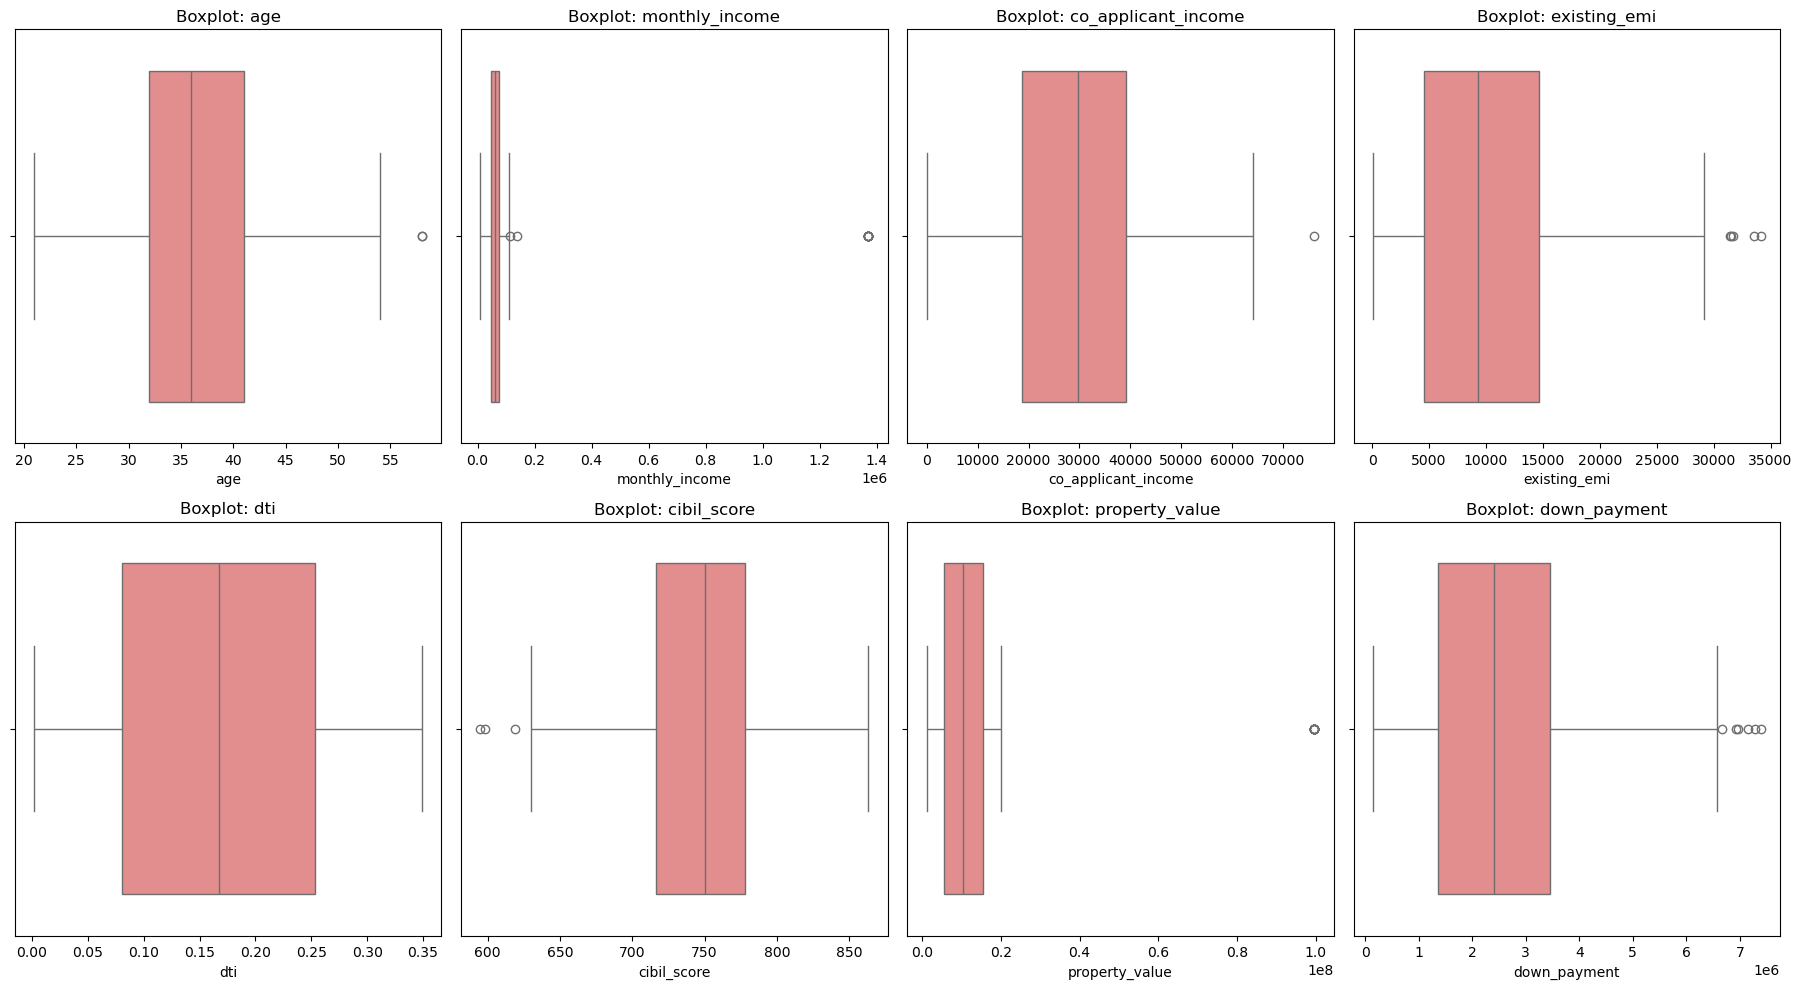

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols[:8]):
    sns.boxplot(x=df[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

### 4.3 — Correlation Heatmap

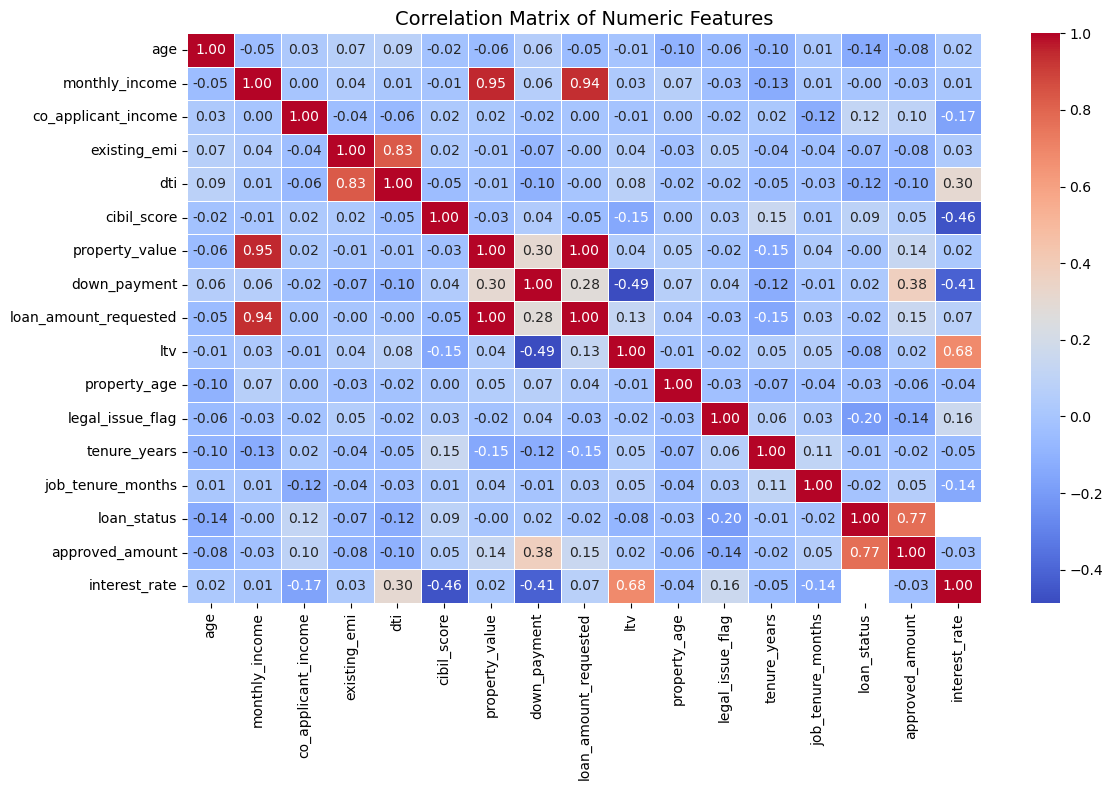

In [10]:
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

### 4.4 — Income vs Loan Approval

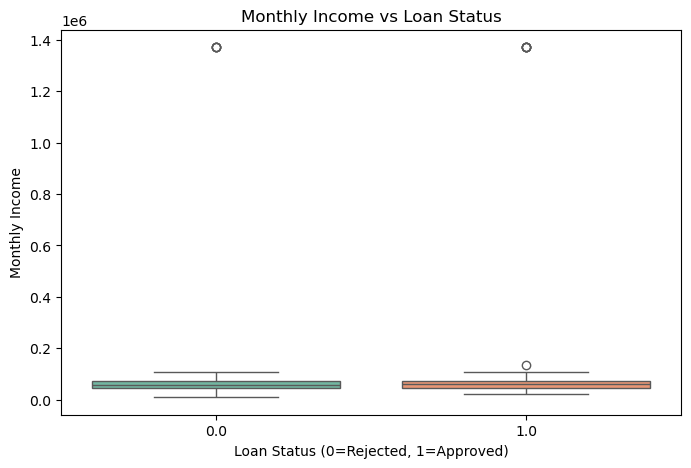

In [11]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='loan_status', y='monthly_income', data=df, palette='Set2')
plt.title('Monthly Income vs Loan Status')
plt.xlabel('Loan Status (0=Rejected, 1=Approved)')
plt.ylabel('Monthly Income')
plt.show()

### 4.5 — City Tier & Employment Type Distribution

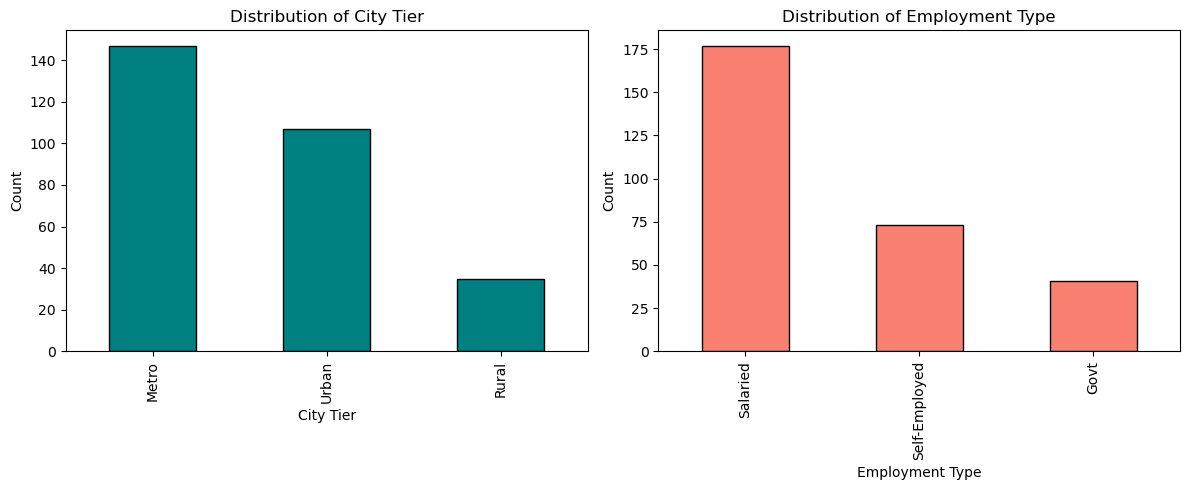

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['city_tier'].value_counts().plot(kind='bar', ax=axes[0], color='teal', edgecolor='black')
axes[0].set_title('Distribution of City Tier')
axes[0].set_xlabel('City Tier')
axes[0].set_ylabel('Count')

df['employment_type'].value_counts().plot(kind='bar', ax=axes[1], color='salmon', edgecolor='black')
axes[1].set_title('Distribution of Employment Type')
axes[1].set_xlabel('Employment Type')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 🧹 Step 5: Data Preprocessing

### 5.1 — Drop Unnecessary Columns

In [13]:
df = df.drop(columns=['name'], errors='ignore')
print("Columns after dropping 'name':", df.shape[1])

Columns after dropping 'name': 20


### 5.2 — Outlier Removal (IQR on monthly_income)

In [14]:
Q1 = df['monthly_income'].quantile(0.25)
Q3 = df['monthly_income'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_clean = df[(df['monthly_income'] >= lower) & (df['monthly_income'] <= upper)].copy()
print(f"Original: {df.shape[0]} rows → After Outlier Removal: {df_clean.shape[0]} rows")
df = df_clean

Original: 315 rows → After Outlier Removal: 279 rows


### 5.3 — Missing Value Imputation

In [15]:
# Numerical → median
num_cols = df.select_dtypes(include='number').columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical → mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after imputation:")
print(df.isnull().sum().sum(), "total missing values")

Missing values after imputation:
0 total missing values


## ⚙️ Step 6: Feature Engineering

In [16]:
# Total income (applicant + co-applicant)
df['total_income'] = df['monthly_income'] + df['co_applicant_income']

# EMI Burden Ratio — zyada EMI = high chance of rejection
df['emi_ratio'] = df['existing_emi'] / (df['monthly_income'] + 1)

# Loan to Income Ratio
df['loan_income_ratio'] = df['loan_amount_requested'] / (df['monthly_income'] + 1)

# Property Age Group
df['property_age_group'] = pd.cut(
    df['property_age'],
    bins=[0, 5, 15, 30, 100],
    labels=['New', 'Moderate', 'Old', 'Very Old']
)

# Loan Amount per Tenure Year
df['loan_per_year'] = df['loan_amount_requested'] / (df['tenure_years'] + 1)

# Log Transformation on monthly_income (skewness reduce)
df['monthly_income'] = np.log1p(df['monthly_income'])

print("New features added:")
print(['total_income', 'emi_ratio', 'loan_income_ratio', 'property_age_group', 'loan_per_year'])
df.shape

New features added:
['total_income', 'emi_ratio', 'loan_income_ratio', 'property_age_group', 'loan_per_year']


(279, 25)

### 6.1 — Encoding Categorical Variables

In [17]:
df_encoded = pd.get_dummies(df, drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head(3)

Shape after encoding: (279, 30)


,age,monthly_income,co_applicant_income,existing_emi,dti,cibil_score,property_value,down_payment,loan_amount_requested,ltv,...,loan_per_year,city_tier_Rural,city_tier_Urban,employment_type_Salaried,employment_type_Self-Employed,builder_grade_B,builder_grade_C,property_age_group_Moderate,property_age_group_Old,property_age_group_Very Old
0,34.0,11.155322,17565.0,5611.0,0.080,818.0,7213630.0,2424292.0,4789338.0,0.664,...,228063.714286,False,False,True,False,False,False,False,False,True
1,25.0,10.954938,21597.0,14468.0,0.253,690.0,13684274.0,2663262.0,11021012.0,0.805,...,524810.095238,True,False,True,False,True,False,False,False,True
2,36.0,11.197598,41209.0,18385.0,0.252,789.0,16349073.0,2275920.0,11339056.0,0.694,...,539955.047619,False,False,True,False,True,False,False,True,False


---
## 🎯 PART 1: Classification — Loan Approval Prediction
**Target:** `loan_status` (0 = Rejected, 1 = Approved)


### Setup: Features & Target Split

In [18]:
# Drop rows where target is null
df_cls = df_encoded.dropna(subset=['loan_status']).copy()

X = df_cls.drop('loan_status', axis=1)
y = df_cls['loan_status']

# Fill any remaining nulls
X = X.fillna(X.median(numeric_only=True))

# Train-Test Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print(f"Target distribution (test): {dict(y_test.value_counts())}")

Train size: (223, 29), Test size: (56, 29)
Target distribution (test): {1.0: np.int64(33), 0.0: np.int64(23)}


### Algorithm 1: Random Forest Classifier

In [19]:
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)

print("=" * 50)
print("📌 RANDOM FOREST CLASSIFIER RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f} ({accuracy_score(y_test, y_pred_rf)*100:.1f}%)")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Rejected', 'Approved']))

📌 RANDOM FOREST CLASSIFIER RESULTS
Accuracy: 0.9643 (96.4%)

Confusion Matrix:
[[21  2]
 [ 0 33]]

Classification Report:
              precision    recall  f1-score   support

    Rejected       1.00      0.91      0.95        23
    Approved       0.94      1.00      0.97        33

    accuracy                           0.96        56
   macro avg       0.97      0.96      0.96        56
weighted avg       0.97      0.96      0.96        56



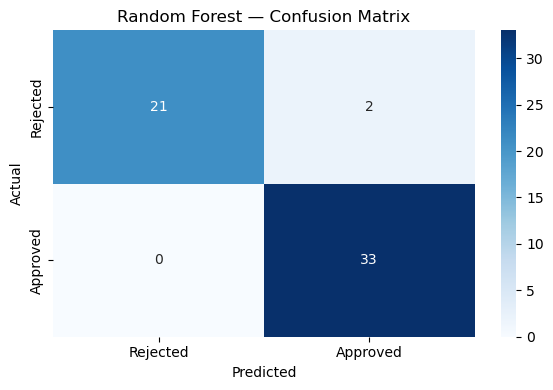

In [20]:
# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

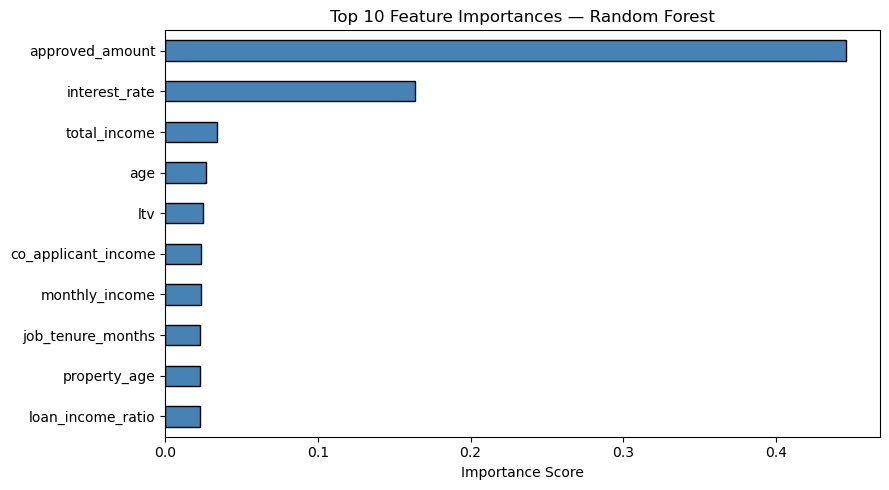

In [21]:
# Feature Importance Plot
feat_imp = pd.Series(rf_clf.feature_importances_, index=X.columns)
top_features = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(9, 5))
top_features.plot(kind='barh', color='steelblue', edgecolor='black')
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Algorithm 2: Logistic Regression

In [22]:
log_reg = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

print("=" * 50)
print("📌 LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f} ({accuracy_score(y_test, y_pred_lr)*100:.1f}%)")
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Rejected', 'Approved']))

📌 LOGISTIC REGRESSION RESULTS
Accuracy: 0.9286 (92.9%)

Confusion Matrix:
[[22  1]
 [ 3 30]]

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.88      0.96      0.92        23
    Approved       0.97      0.91      0.94        33

    accuracy                           0.93        56
   macro avg       0.92      0.93      0.93        56
weighted avg       0.93      0.93      0.93        56



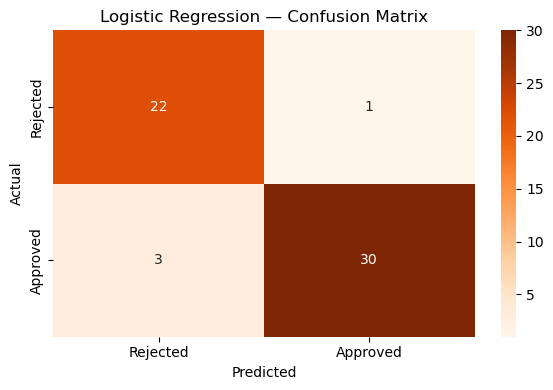

In [23]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Classification Model Comparison

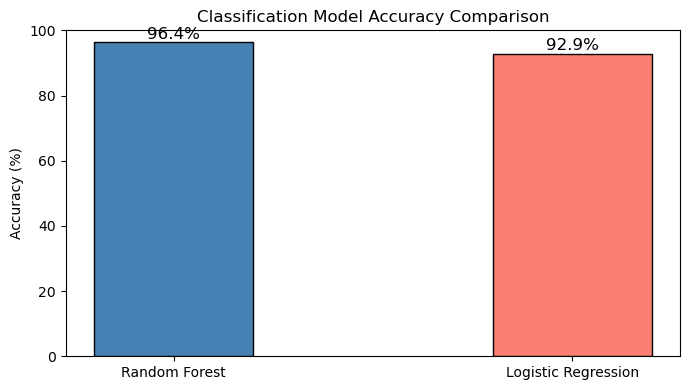

In [24]:
models = ['Random Forest', 'Logistic Regression']
accuracies = [
    accuracy_score(y_test, y_pred_rf) * 100,
    accuracy_score(y_test, y_pred_lr) * 100
]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, accuracies, color=['steelblue', 'salmon'], edgecolor='black', width=0.4)
plt.ylim(0, 100)
plt.title('Classification Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{acc:.1f}%', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

---
## 📈 PART 2: Regression — Loan Amount Prediction
**Target:** `loan_amount_requested`


In [25]:
# Features & Target
df_reg = df_encoded.copy().fillna(df_encoded.median(numeric_only=True))

X_reg = df_reg.drop('loan_amount_requested', axis=1)
y_reg = df_reg['loan_amount_requested']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Impute & Scale
imputer = SimpleImputer(strategy='median')
X_train_r = imputer.fit_transform(X_train_r)
X_test_r = imputer.transform(X_test_r)

scaler_reg = StandardScaler()
X_train_r = scaler_reg.fit_transform(X_train_r)
X_test_r = scaler_reg.transform(X_test_r)

print(f"Regression Train: {X_train_r.shape}, Test: {X_test_r.shape}")

Regression Train: (223, 29), Test: (56, 29)


### Algorithm 1: Linear Regression

In [26]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_r, y_train_r)
y_pred_lin = lin_reg.predict(X_test_r)

r2_lin = r2_score(y_test_r, y_pred_lin)
print("=" * 50)
print("📌 LINEAR REGRESSION RESULTS")
print("=" * 50)
print(f"R² Score: {r2_lin:.4f} ({r2_lin*100:.2f}%)")

📌 LINEAR REGRESSION RESULTS
R² Score: 0.9106 (91.06%)


### Algorithm 2: Random Forest Regressor

In [27]:
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train_r, y_train_r)
y_pred_rfr = rf_reg.predict(X_test_r)

r2_rfr = r2_score(y_test_r, y_pred_rfr)
print("=" * 50)
print("📌 RANDOM FOREST REGRESSOR RESULTS")
print("=" * 50)
print(f"R² Score: {r2_rfr:.4f} ({r2_rfr*100:.2f}%)")

📌 RANDOM FOREST REGRESSOR RESULTS
R² Score: 0.8886 (88.86%)


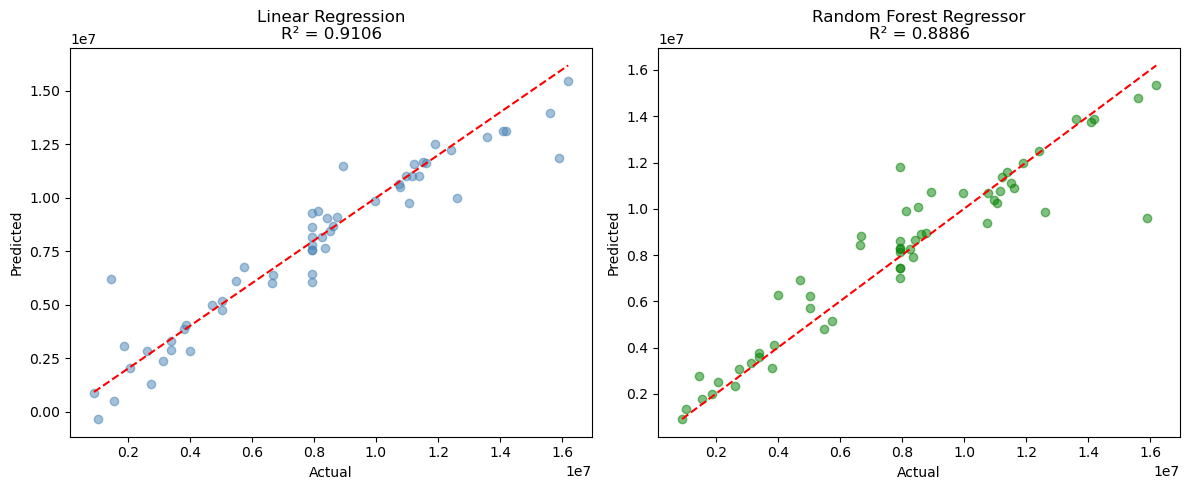

In [28]:
# Actual vs Predicted Plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_r, y_pred_lin, alpha=0.5, color='steelblue')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.title(f'Linear Regression\nR² = {r2_lin:.4f}')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.subplot(1, 2, 2)
plt.scatter(y_test_r, y_pred_rfr, alpha=0.5, color='green')
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--')
plt.title(f'Random Forest Regressor\nR² = {r2_rfr:.4f}')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

### Regression Model Comparison

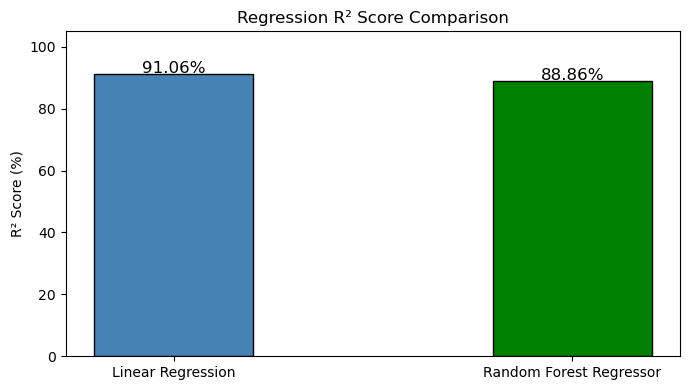

In [29]:
models_r = ['Linear Regression', 'Random Forest Regressor']
r2_scores = [r2_lin * 100, r2_rfr * 100]

plt.figure(figsize=(7, 4))
bars = plt.bar(models_r, r2_scores, color=['steelblue', 'green'], edgecolor='black', width=0.4)
plt.ylim(0, 105)
plt.title('Regression R² Score Comparison')
plt.ylabel('R² Score (%)')
for bar, sc in zip(bars, r2_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f'{sc:.2f}%', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

---
## 🔵 PART 3: Clustering — Customer Segmentation
**Algorithm:** KMeans (k=3)


In [30]:
# Features for clustering
df_clus = df_encoded.copy().fillna(df_encoded.median(numeric_only=True))

cluster_features = df_clus[['total_income', 'emi_ratio', 'loan_income_ratio']]

scaler_clus = StandardScaler()
cluster_scaled = scaler_clus.fit_transform(cluster_features)

print("Clustering features shape:", cluster_scaled.shape)

Clustering features shape: (279, 3)


### Elbow Method — Optimal k

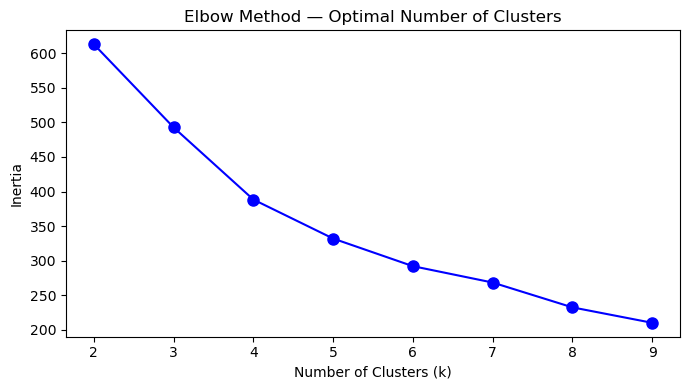

In [31]:
inertia = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(cluster_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

### KMeans with k=3

In [32]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_clus['Cluster'] = kmeans.fit_predict(cluster_scaled)

print("Cluster Distribution:")
print(df_clus['Cluster'].value_counts())

Cluster Distribution:
Cluster
1    115
0     82
2     82
Name: count, dtype: int64


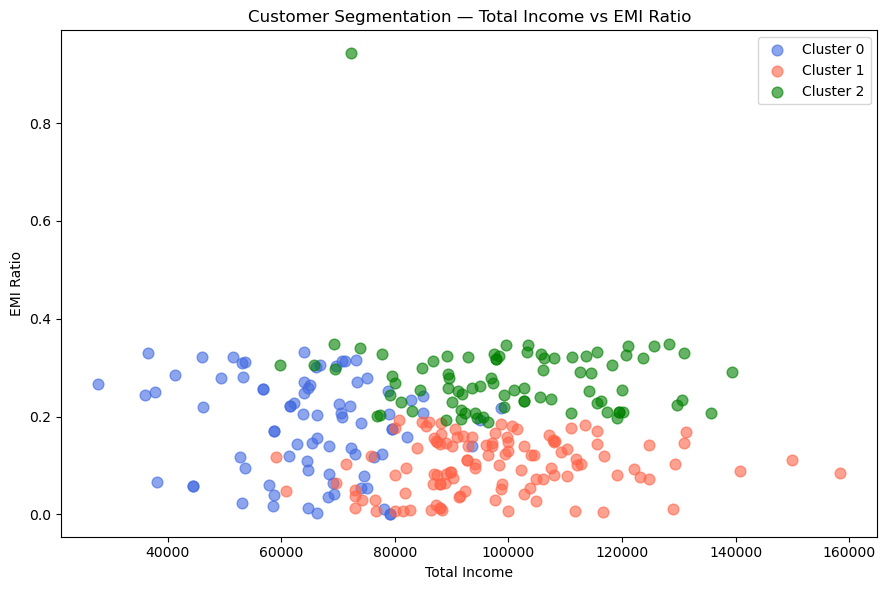

In [33]:
# Cluster Visualization
plt.figure(figsize=(9, 6))
colors = ['royalblue', 'tomato', 'green']
labels = ['Cluster 0', 'Cluster 1', 'Cluster 2']

for i in range(3):
    mask = df_clus['Cluster'] == i
    plt.scatter(
        df_clus.loc[mask, 'total_income'],
        df_clus.loc[mask, 'emi_ratio'],
        label=labels[i], alpha=0.6, s=60, color=colors[i]
    )

plt.title('Customer Segmentation — Total Income vs EMI Ratio')
plt.xlabel('Total Income')
plt.ylabel('EMI Ratio')
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
# Cluster Profile Summary
cluster_summary = df_clus.groupby('Cluster')[['total_income', 'emi_ratio', 'loan_income_ratio']].mean()
print("Cluster Profiles (Mean Values):")
cluster_summary

Cluster Profiles (Mean Values):


,total_income,emi_ratio,loan_income_ratio
Cluster,,,
0,65186.439024,0.180011,237.444102
1,97557.808696,0.100391,106.156987
2,100499.975610,0.277903,110.315060
